# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** [To be provided]

**Date:** [To be provided]

# Your Phase 1 solution to the problem goes here.
Decleration: I have completed this version without generative AI.
Student(s): Jacob Khaykin
Date: 9/2/2026

Q1 1. I cleaned the price variable by noticing that values above 999 (like in the thousands) include a comma to seperate the numbers (i.e. 2,300). Therefore, I used the replace method to replace every comma with nothing else to remove it. After cleaning it up like that, there were no more missing values. 

Q1 2. The subject_injury variables already looks pretty clean but with a lot of missing values. I found that there are 9848 missing values in subject_injury and the proportion of missing values in subject_injury from the total is 0.76 which is very significant and definitely concerning. After cross tabulating the cleaned subject_inquiry variable with the force_type variable, I found that the all of the less lethal force was under the NaN catagory, and the proportion of bodily force, taser, and chemical irritant that was NaN was very high.

Q2 The attacks are increasing over time. The range is very big stemming fomr 0 to 2026, with values before 1940 that I filtered out through year < 1500 to focus on attacks after 1940. I cleared and filtered those values out for the sake of the exercise. The histogram of the age variables has been made. looks like a right skewed curve with more attacks happening around 18-20 years old. The proportion male is 0.86. After I cleaned the Type variable, the proportion of unprovoked incidents is 0.746.

df.shape:
(30478, 13) 

df.dtypes:
Host Id                         int64
Host Since                        str
Name                              str
Neighbourhood                     str
Property Type                     str
Review Scores Rating (bin)    float64
Room Type                         str
Zipcode                       float64
Beds                          float64
Number of Records               int64
Number Of Reviews               int64
Price                             str
Review Scores Rating          float64
dtype: object 

df.head():
    Host Id Host Since                                Name Neighbourhood   \
0   5162530        NaN     1 Bedroom in Prime Williamsburg       Brooklyn   
1  33134899        NaN     Sunny, Private room in Bushwick       Brooklyn   
2  39608626        NaN                Sunny Room in Harlem      Manhattan   
3       500  6/26/2008  Gorgeous 1 BR with Private Balcony      Manhattan   
4       500  6/26/2008            Trendy Times Square Loft 

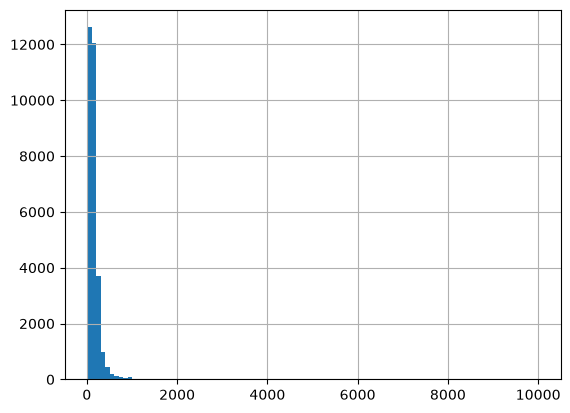

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('data/airbnb_hw.csv', low_memory=False)
print("df.shape:")
print(df.shape, '\n')

print("df.dtypes:")
print(df.dtypes, '\n')

print("df.head():")
print(df.head())

var = 'Price'
print(df[var].unique(), '\n')
print(df[var].value_counts(), '\n')

df[var] = df[var].replace(",", "", regex=True)

df[var] = pd.to_numeric(df[var], errors='coerce')
df['price_nan'] = df[var].isnull()


print('After coercion:\n', df[var].describe(), '\n')
df[var].hist(bins=100)
print('Total missings (if any):\n', sum(df['price_nan']), '\n')



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('data/mn_police_use_of_force.csv', low_memory=False)
print("df.shape:")
print(df.shape, '\n')

print("df.dtypes:")
print(df.dtypes, '\n')

print("df.head():")
print(df.head())

var = 'subject_injury'
print(df[var].unique(), '\n')
df[var] = df[var].replace(' ', np.nan) ## doesn't do anything but I think its good practice to handle
print(df[var].value_counts(dropna=False), '\n') ##showcases different counts and how massive the Nan is for if there was an injury
print(df[var].isnull().sum(), 'missing values in', var)
print('Proportion of missing values in', var, ':', df[var].isnull().sum() / (df[var].notnull().sum() + df[var].isnull().sum()))

pd.crosstab(df[var], df['force_type'], dropna=False)

df.shape:
(12925, 13) 

df.dtypes:
response_datetime        str
problem                  str
is_911_call              str
primary_offense          str
subject_injury           str
force_type               str
force_type_action        str
race                     str
sex                      str
age                  float64
type_resistance          str
precinct               int64
neighborhood             str
dtype: object 

df.head():
     response_datetime               problem is_911_call primary_offense  \
0  2016/01/01 00:47:36  Assault in Progress          Yes          DASLT1   
1  2016/01/01 02:19:34                Fight           No          DISCON   
2  2016/01/01 02:19:34                Fight           No          DISCON   
3  2016/01/01 02:28:48                Fight           No          PRIORI   
4  2016/01/01 02:28:48                Fight           No          PRIORI   

  subject_injury         force_type   force_type_action   race     sex   age  \
0            NaN       B

force_type,Baton,Bodily Force,Chemical Irritant,Firearm,Gun Point Display,Improvised Weapon,Less Lethal,Less Lethal Projectile,Maximal Restraint Technique,Police K9 Bite,Taser
subject_injury,,,,,,,,,,,
No,0,1093,131,2,33,34,0,1,0,2,150
Yes,2,1286,41,0,44,40,0,2,0,44,172
NaN,2,7051,1421,0,27,74,87,0,170,31,985


           Date    Year        Type         Country                    State  \
0   26th August  2026.0  Unprovoked             USA                   Hawaii   
1  23rd August   2026.0  Unprovoked             USA                  Florida   
2   19th August  2026.0    Provoked  Reunion Island  Saint-Gilles-les-Baines   
3   11th August  2026.0    Provoked         Ireland                Waterford   
4    8th August  2026.0  Unprovoked             USA                    Maine   

                           Location                     Activity  \
0       Ala Moana Beach Park, Oah'u                      Surfing   
1  Boca Grande (island in the keys)          Wading on a sandbar   
2          Outer Reef Roches Noires                Spearfishiong   
3                   Ardemore County                      Fishing   
4            Scarborough Beach Park  Operation of Rescue Torpedo   

              Name Sex Age  ...                    Species   \
0   Unknown Female   F   ?  ...                

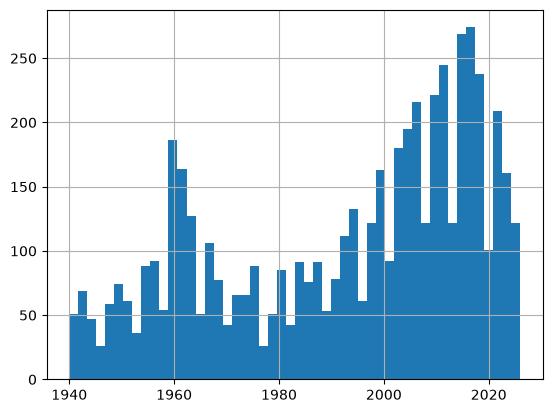

1936 ages could not be parsed


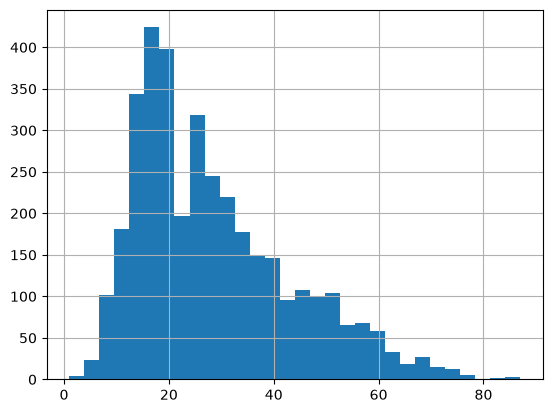

Sex
M        4384
F         730
NaN       451
M           7
?           2
F           2
M F         1
 M          1
m           1
lli         1
M x 2       1
Name: count, dtype: int64
Proportion male: 0.8572545952287838
Type
Unprovoked             4161
Provoked                526
Invalid                 402
Watercraft              280
Sea Disaster            156
Questionable             27
NaN                      14
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64
Type
Unprovoked    4163
Unknown        890
Provoked       528
Name: count, dtype: int64
The proportion of unprovoked incidents: 0.7459236695932628


In [81]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xlrd

df = pd.read_excel('data/GSAF5.xls')
print(df.head())
print(df.isna().mean().sort_values())
df = df.drop(columns=['Unnamed: 21', 'Unnamed: 22'])
print(df['Year'].describe())
df.loc[df['Year'] < 1500, 'Year'] = np.nan
print("Missing and small Year values total: ", df['Year'].isnull().sum())
df = df[df['Year'] >= 1940] 
df['Year'].hist(bins=50)
plt.show()

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
print(df['Age'].isna().sum(), 'ages could not be parsed')
df['Age'].hist(bins=30)
plt.show()

print(df['Sex'].value_counts(dropna=False))     # look at the mess first

male = (df['Sex'] == 'M').sum()
female = (df['Sex'] == 'F').sum()
print('Proportion male:', male / (male + female))

print(df['Type'].value_counts(dropna=False))

df['Type'] = df['Type'].replace({' Provoked': 'Provoked', 'UNprovoked': 'Unprovoked', 'unprovoked': 'Unprovoked'})
df.loc[(df['Type'] != 'Provoked') & (df['Type'] != 'Unprovoked'), 'Type'] = 'Unknown'

print(df['Type'].value_counts())

print("The proportion of unprovoked incidents:", (df['Type'] == 'Unprovoked').sum() / df['Type'].notnull().sum())

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** [To be provided]
- **AI tool and model used:** [To be provided]

### *Prompts used

1. [Paste prompt]
2. [Paste follow-up prompt]

### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. ...
2. ...

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept / modify / reject | ... |
| 2 | Accept / modify / reject | ... |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.


### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]